# Punxsutawney Phil vs. Philadelphia: Does the Groundhog Actually Know Anything?

Every February 2, a groundhog called Puxsutawney Phil in Pennsylvania tells us one of two things:

* ❄️ **More winter** (he saw his shadow)
* 🌼 **Early spring** (no shadow)

So I wanted to test the legend using **daily Philadelphia weather from 2005–2025**.

### My questions

I’m looking specifically at the **six weeks after Groundhog Day** (Feb 2 → ~mid-March):

1. What is the *typical* weather like in Philly during those six weeks?
2. Do temperature patterns look different in “more winter” vs “early spring” years?
3. Do “early spring” years warm up faster?
4. How much does late-winter weather vary year to year anyway?
5. Overall… is Phil’s prediction meaningfully related to actual Philly weather?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Philly weather
weather_df = pd.read_csv('data/philadelphia_weather_2005_to_2025.csv')
weather_df['date'] = pd.to_datetime(weather_df['date'])

weather_df.head()

,day,year,high,low,rain,snow,date,day_num,month_num,dow,dow_name,month
0,January 1,2005,64,39,0.00,0.0,2005-01-01,1,1,5,Saturday,January
1,January 2,2005,47,33,0.01,0.0,2005-01-02,2,1,6,Sunday,January
2,January 3,2005,57,40,0.06,0.0,2005-01-03,3,1,0,Monday,January
3,January 4,2005,55,44,0.00,0.0,2005-01-04,4,1,1,Tuesday,January
4,January 5,2005,47,36,0.62,0.0,2005-01-05,5,1,2,Wednesday,January


In [2]:
headers = {
    "User-Agent": "Mozilla/5.0"
}

url = "https://www.groundhog.org/groundhog-day/history-past-predictions/"
tables = pd.read_html(url, storage_options=headers)

predict_df = tables[0].copy()
predict_df = predict_df.rename(columns={"Year":"year", "Prediction":"prediction_raw"})

# Keep 2005–2025 only
predict_df = predict_df.query("year >= 2005 and year <= 2025").copy()

# Clean into simple labels
def clean_pred(x):
    x = str(x)
    if "More winter" in x:
        return "More winter"
    if "Early spring" in x:
        return "Early spring"
    return "Other/None"

predict_df["prediction"] = predict_df["prediction_raw"].apply(clean_pred)

predict_df["prediction"].value_counts()


prediction
More winter     14
Early spring     7
Name: count, dtype: int64

## Defining “six weeks after Groundhog Day”

Phil’s prediction is about what happens next, so I’m focusing on the period starting February 2, all the way through the next 6 weeks.

That window matters because it’s when we feel winter dragging on or not.


## Q1) What’s the typical Philly weather in the 6 weeks after Feb 2?

This is the part where Philly *can’t decide what it wants to be*.

Instead of picking one day, I looked at the whole February to mid-March window across 21 years and summarized:

* **Daily highs and lows** (how warm/cold it feels)
* **Rain and snow** (how messy it gets)


In [3]:
# Build a Feb 2 date for every year in the dataset
ghday = pd.to_datetime(dict(year=weather_df["date"].dt.year, month=2, day=2))
winter_end = ghday + pd.Timedelta(weeks=6)

winter_filter = (weather_df["date"] >= ghday) & (weather_df["date"] <= winter_end)
winter_weather = weather_df.loc[winter_filter].copy()

# Q1: "Typical" weather over all years in that window
typical = winter_weather[["high","low","rain","snow"]].describe().round(2)
typical


,high,low,rain,snow
count,903.00,903.00,903.00,903.00
mean,47.41,30.73,0.11,0.24
std,11.59,8.58,0.28,1.21
min,17.00,2.00,0.00,0.00
25%,39.00,26.00,0.00,0.00
50%,46.00,31.00,0.00,0.00
75%,55.00,36.00,0.05,0.00
max,82.00,57.00,2.57,21.90


## Q2) “More winter” vs “Early spring”: do the temperature patterns differ?

To test Phil’s actual claim, I grouped years by his prediction and compared what Philly weather did in the six-week window.

* If “Early spring” years are truly different, their temperatures should sit higher.
* If the boxes overlap heavily, then unfortunately the groundhog may be wrong.


In [4]:
winter_yearly = (
    winter_weather
    .groupby("year")[["high","low","rain","snow"]]
    .agg({
        "high":[np.mean, np.min, np.max],
        "low":[np.mean, np.min, np.max],
        "rain":[np.sum],
        "snow":[np.sum]
    })
)
winter_yearly.columns = ["_".join([c[0], c[1]]) for c in winter_yearly.columns]
winter_yearly = winter_yearly.reset_index()


In [5]:
# Merge predictions with yearly weather summary
winter_merged = winter_yearly.merge(predict_df[["year","prediction"]], on="year", how="inner")
winter_merged["prediction"].value_counts()

prediction
More winter     14
Early spring     7
Name: count, dtype: int64

In [6]:
# Compare group means (Q2)
group_summary = (
    winter_merged
    .groupby("prediction")[["high_mean","low_mean","rain_sum","snow_sum"]]
    .mean()
    .round(2)
)

group_summary


,high_mean,low_mean,rain_sum,snow_sum
prediction,,,,
Early spring,47.96,31.48,4.97,5.31
More winter,47.13,30.35,4.49,12.60


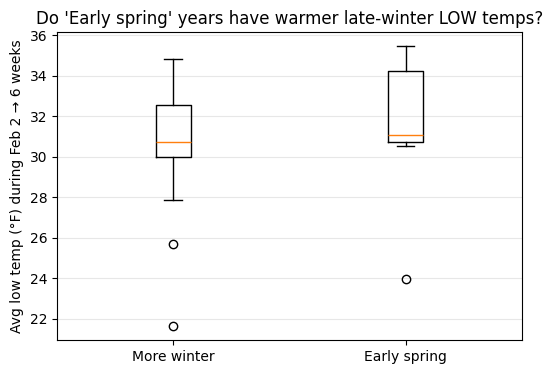

In [7]:
# Boxplot of average lows by prediction group
groups = ["More winter", "Early spring"]
data = [winter_merged.loc[winter_merged["prediction"]==g, "low_mean"] for g in groups]

plt.figure(figsize=(6,4))
plt.boxplot(data, tick_labels=groups)
plt.title("Do 'Early spring' years have warmer late-winter LOW temps?")
plt.ylabel("Avg low temp (°F) during Feb 2 → 6 weeks")
plt.grid(True, axis="y", alpha=0.3)
plt.show()


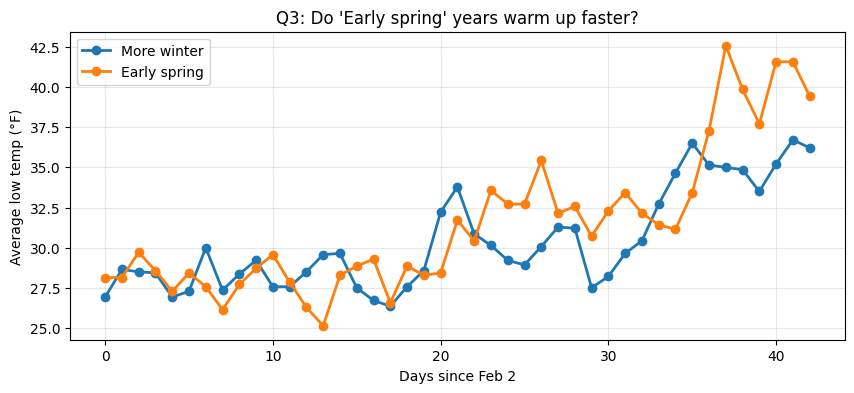

In [8]:
# Add "day since Feb 2" index within each year
winter_weather = winter_weather.copy()
winter_weather["day_since_gh"] = (winter_weather["date"] - pd.to_datetime(dict(year=winter_weather["year"], month=2, day=2))).dt.days

# Merge prediction onto daily rows
winter_daily = winter_weather.merge(predict_df[["year","prediction"]], on="year", how="inner")

# Average trajectory by group (mean low temp each day index)
traj = (
    winter_daily
    .groupby(["prediction","day_since_gh"])[["high","low"]]
    .mean()
    .reset_index()
)

# Plot LOW trajectory
plt.figure(figsize=(10,4))
for g in ["More winter", "Early spring"]:
    sub = traj[traj["prediction"]==g]
    plt.plot(sub["day_since_gh"], sub["low"], marker="o", linewidth=2, label=g)

plt.title("Q3: Do 'Early spring' years warm up faster?")
plt.xlabel("Days since Feb 2")
plt.ylabel("Average low temp (°F)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [9]:
# Compute a simple slope per year: low ~ day_since_gh
slopes = []
for yr, df_yr in winter_daily.groupby("year"):
    x = df_yr["day_since_gh"].values
    y = df_yr["low"].values
    # polyfit slope
    slope = np.polyfit(x, y, 1)[0]
    pred = df_yr["prediction"].iloc[0]
    slopes.append({"year": yr, "prediction": pred, "warming_slope_low_per_day": slope})

slopes_df = pd.DataFrame(slopes)

slopes_df.groupby("prediction")["warming_slope_low_per_day"].describe().round(3)


,count,mean,std,min,25%,50%,75%,max
prediction,,,,,,,,
Early spring,7.0,0.298,0.107,0.170,0.213,0.286,0.387,0.429
More winter,14.0,0.191,0.159,-0.095,0.129,0.203,0.297,0.479


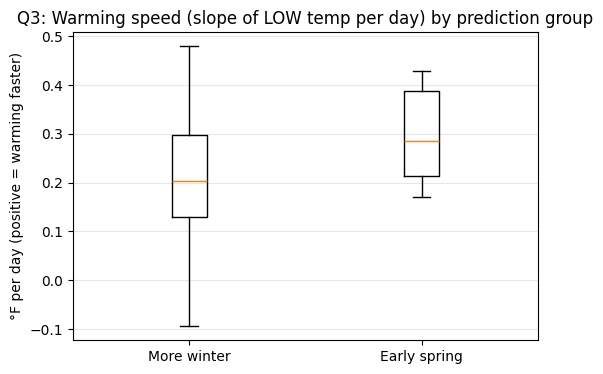

In [10]:
# Boxplot slopes by group
data = [slopes_df.loc[slopes_df["prediction"]==g, "warming_slope_low_per_day"] for g in ["More winter","Early spring"]]

plt.figure(figsize=(6,4))
plt.boxplot(data, tick_labels=["More winter","Early spring"])
plt.title("Q3: Warming speed (slope of LOW temp per day) by prediction group")
plt.ylabel("°F per day (positive = warming faster)")
plt.grid(True, axis="y", alpha=0.3)
plt.show()


## Q4) The big twist: late-winter is *wildly different* year to year

Before I even separate “more winter” vs “early spring,” one thing jumps out:

Some years are **consistently cold** across the whole six-week stretch.
Other years it is already quite warm by late February.

So if Phil is going to be right, he’s predicting into a system that already has huge natural variation.

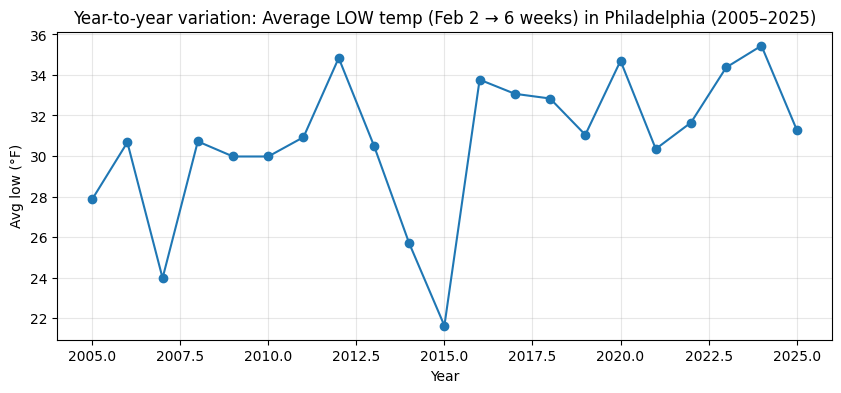

In [11]:
# Summarize each year's 6-week window
winter_yearly = (
    winter_weather
    .groupby("year")[["high","low","rain","snow"]]
    .agg({
        "high":[np.mean, np.min, np.max],
        "low":[np.mean, np.min, np.max],
        "rain":[np.sum],
        "snow":[np.sum]
    })
)

winter_yearly.columns = ["_".join([c[0], c[1]]) for c in winter_yearly.columns]
winter_yearly = winter_yearly.reset_index()

# Plot year-to-year average lows (variation)
plt.figure(figsize=(10,4))
plt.plot(winter_yearly["year"], winter_yearly["low_mean"], marker="o")
plt.title("Year-to-year variation: Average LOW temp (Feb 2 → 6 weeks) in Philadelphia (2005–2025)")
plt.xlabel("Year")
plt.ylabel("Avg low (°F)")
plt.grid(True, alpha=0.3)
plt.show()


## Q5) Final verdict: is Phil meaningfully related to Philly weather?

Here’s what I take away after comparing 2005–2025:

* Philly’s late-winter weather has **big year-to-year variation** no matter what Phil says.
* “Early spring” years may look a bit warmer in some summaries, but the overlap is usually big enough that it’s hard to treat the prediction as reliable.

### So should you trust the groundhog?

Unfortunately, while it may be fun to believe in this myth, the groundhod is not a reliable source. You should still always remember to have a jacket handy with you in February and March, but sometimes it may be a bit warmer simply because of weather variations.
